In [18]:
from selenium import webdriver as wb
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.common.by import By
from bs4 import BeautifulSoup as bs
from tqdm import tqdm
import time
# os: 파일 및 폴더 시스템 관리 모듈
import os
# urlretrieve: url 경로를 통해 데이터를 파일로 다운로드 시켜주는 함수
from urllib.request import urlretrieve
import requests as req

In [9]:
!pip install selenium bs4 tqdm

  Using cached selenium-4.44.0-py3-none-any.whl.metadata (7.4 kB)
  Using cached bs4-0.0.2-py2.py3-none-any.whl.metadata (411 bytes)
  Using cached certifi-2026.5.20-py3-none-any.whl.metadata (2.5 kB)
  Using cached trio-0.33.0-py3-none-any.whl.metadata (8.5 kB)
  Using cached trio_websocket-0.12.2-py3-none-any.whl.metadata (5.1 kB)
  Using cached urllib3-2.7.0-py3-none-any.whl.metadata (6.9 kB)
  Using cached outcome-1.3.0.post0-py2.py3-none-any.whl.metadata (2.6 kB)
  Using cached wsproto-1.3.2-py3-none-any.whl.metadata (5.2 kB)
Using cached selenium-4.44.0-py3-none-any.whl (9.7 MB)
Using cached trio-0.33.0-py3-none-any.whl (510 kB)
Using cached trio_websocket-0.12.2-py3-none-any.whl (21 kB)
Using cached urllib3-2.7.0-py3-none-any.whl (131 kB)
Using cached bs4-0.0.2-py2.py3-none-any.whl (1.2 kB)
Using cached certifi-2026.5.20-py3-none-any.whl (134 kB)
Using cached outcome-1.3.0.post0-py2.py3-none-any.whl (10 kB)
Using cached wsproto-1.3.2-py3-none-any.whl (24 kB)

  Attempting uninst

### 수집된 이미지가 저장될 폴더 설정
- 폴더가 없으면 생성되고 있으면 그대로

In [ ]:
if not os.path.isdir("이미지"):
    os.mkdir("이미지")      # 이미지 폴더를 만들기
    print("해당 경로에 폴더를 생성합니다.")
else:
    print("해당 경로에 폴더가 존재합니다.")  # 중복되어서 폴더가 생성되지 않는다.

### 네이버 검색창에 원하는 검색어로 검색 후 이미지 탭에서 url 복사

In [ ]:
driver = wb.Chrome()
driver.maximize_window()
time.sleep(2)

driver.get("https://search.naver.com/search.naver?ssc=tab.image.all&where=image&sm=tab_jum&query=%EC%9B%94%EB%93%9C%EC%BB%B5")

### 이미지 요소들 추출
- 첫번째 방법 : BeautifulSoup 활용

In [ ]:
# 수집하려는 데이터가 이미지 이기 때문에 text 대신 page_source를 활용
# page_source: HTML 페이지의 소스 정보를 요청하는 인자
soup = bs(driver.page_source, "lxml")
soup

In [ ]:
imgs_bs = soup.select("img._fe_image_tab_content_thumbnail_image")
#imgs_bs[0].text # img태그 내 텍스트가 없었으므로 안나오는게 정상

In [ ]:
len(imgs_bs)

In [ ]:
imgs_bs

- 이미지 데이터는 컨텐츠가 아닌 실제 이미지가 들어있는 주소인 src속성 값을 확인해야 함
- 이미지는 텍스트 데이터에 비해 용량이 크기 때문에 HTML요소에 접근을 했더라도 모든 이미지를 다 로드해놓지 않는 경우가 있음(스크롤을 내려주면 대부분 확인 가능)

In [ ]:
# bs에서 속성에 접근하기 위해서는 [] 사용
imgs_bs[0]["src"]

- 두번째 방법: Selenium 활용

In [ ]:
imgs_sel = driver.find_elements(By.CSS_SELECTOR, "img._fe_image_tab_content_thumbnail_image")
len(imgs_sel)

In [ ]:
imgs_sel[0].get_attribute("src")

### 각 이미지의 src속성들을 빈 리스트에 담기

In [ ]:
# 이미지 주소만 리스트에 넣기(한 줄 for문)
imgs_src_list = [i.get_attribute("src") for i in imgs_sel]
imgs_src_list

# <동일코드>
# imgs_src_list = []
# for i in imgs_sel :
#       imgs_src_list.append(i.get_attribute("src"))

- 스크롤 하단부에 gif;base64로 표시된 이미지들은 웹 사이트에서 한 번에 모든 고화질 이미지를 다 로딩하면 서버비용도 많이 들고, 속도도 느려지기 때문에 임시로 저장해둔 투명 이미지 주소이며 이를 다 보려면 웹 사이트에서 스크롤을 더 내려서 봐야 함

In [ ]:
# 실제로 로딩된 이미지만 추출
imgs_src_list_new = [i for i in imgs_src_list if i[:5] == "https"]
imgs_src_list_new

# <동일코드>
# imgs_src_list_new = []
# for i in imgs_src_list :
#       if i[:5]=="https":
#       img_src_list_new.append(i)

In [ ]:
len(imgs_src_list), len(imgs_src_list_new)

### 각 이미지 속성들을 이미지 파일로 변환 후, 생성해둔 폴더에 담기

In [ ]:
# enumerate: for문에서 순서가 있는 집합의 인덱스와 요소를 반환해주는 함수# enumerate: for문에서 순서가 있는 집합의 인덱스와 요소를 반환해주는 함수
for idx, img in tqdm(enumerate(imgs_src_list_new)):     # 변수 두개를 받아야함 index와 요소를 받는다. url들이 img로 들어감
    # urlretrieve(url, 경로 및 파일명 설정)
    urlretrieve(img, "이미지/"+str(idx+1)+".jpg")
    time.sleep(0.5)

### 전체 코드를 한 셀에 작성
- 스크롤 내리기 기능을 3번 사용해서 더 많은 이미지를 띄운 후 이미지 다운로드 하기

In [14]:
# 크롬 창 띄우기 및 최대화, 이미지 탭 사이트로 이동
driver = wb.Chrome()
driver.maximize_window()
time.sleep(2)

driver.get("https://search.naver.com/search.naver?ssc=tab.image.all&where=image&sm=tab_jum&query=%EC%9B%94%EB%93%9C%EC%BB%B5")
# try-except 문을 통해 스크롤 3번 내리고
try:
    for i in range(3):
        body = driver.find_element(By.TAG_NAME, "body")
        body.send_keys(Keys.END)
        time.sleep(2)

        imgs_sel = driver.find_elements(By.CSS_SELECTOR, "img._fe_image_tab_content_thumbnail_image")
        
# 이미지 요소에 접근하여 로드된 이미지들만 리스트에 저장 후 
        imgs_src_list = [i.get_attribute("src") for i in imgs_sel]
        imgs_src_list_new = [i for i in imgs_src_list if i[:5] == "https"]
        
# 이미지폴더에 파일로 다운로드
    for idx, img in tqdm(enumerate(imgs_src_list_new)):     # 변수 두개를 받아야함 index와 요소를 받는다. url들이 img로 들어감
    # urlretrieve(url, 경로 및 파일명 설정)
        urlretrieve(img, "이미지/"+str(idx+1)+".jpg")
        time.sleep(0.5)

    print("크롤링 완료")
    driver.quit()
except Exception as e:
    print("에러명 :",e)

230it [02:02,  1.88it/s]


크롤링 완료


### 데이터가 전부 수집되지 않는 여러가지 이유
1. 웹 페이지 자체의 실시간 변동서으이 심한 경우
    - 빈번한 업데이트, 업로드, 삭제 등으로 수집하려는 대상이 동작중 변경될 수 있음
2. 웹 페이지 별로 구조가 상이한 경우
    - 반응형 웹과 같이 상황에 따라 구조가 변하는 경우, 요소가 있다가 없어지는 현상이 발생할 수 있음
3. 크롤링 시 충분한 시간텀을 주지 않은 경우
    - 웹페이지의 이미지가 다 로딩되기 전에 코드만 동작시키면 인식되지 않을 수 있음
    - 스크롤 후 img태그는 HTML에 있지만 실제 이미지 주소는 아직 브라우저에 로딩되지 않았을 수 있음
4. 수집하려는 데이터 자체가 부족한 경우
    - 특정 희귀한 검색어의 경우 업로드 된 이미지 자체가 적어서 수집이 덜 될 수 있음

### [실습] 구글에서 이미지 검색
- 이미지2 폴더를 만들어서 구글 검색에서 이미지 탭에서 3스크롤 내린 후 이미지 다운호드하기

In [13]:
if not os.path.isdir("이미지2"):
    os.mkdir("이미지2")
    print("해당 경로에 폴더를 생성합니다.")
else:
    print("해당 경로에 폴더가 존재합니다.")

해당 경로에 폴더가 존재합니다.


### 구글 이미지 크롤링 시 '로봇이 아닙니다.' 문구가 뜬다면
- undetected_chromedriver: 구글 봇 탐지 로직을 우회하여 봇이 아닌것으로 인식되게 하는 크롬 버전

In [38]:
!pip install undetected_chromedriver

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for undetected_chromedriver: filename=undetected_chromedriver-3.5.5-py3-none-any.whl size=47214 sha256=947ce397ce040363cbf5b5006afa480b40303eef541c05e3edfae16035207eb0
  Stored in directory: c:\users\jungsoo\appdata\local\pip\cache\wheels\7a\5f\c1\06f68421cc7172ef51504631252870bcb3a2fdf3b6a025f362
Successfully built undetected_chromedriver

   ---------------------------------------- 0/2 [websockets]
   ---------------------------------------- 0/2 [websockets]
   ---------------------------------------- 0/2 [websockets]
   ---------------------------------------- 0/2 [websockets]
   -------------------- ------------------- 1/2 [undetected_chromed

In [3]:
import undetected_chromedriver as us

In [5]:
driver = us.Chrome() # wb 대신 us로 사용함
driver.maximize_window()
time.sleep(2)

driver.get("https://www.google.com/search?sca_esv=e8b56c3c652e1040&rlz=1C1IBEF_koKR942KR942&sxsrf=ANbL-n7umN4LVmISF3gjcq6h4Oi6MzZNGw:1780971175364&udm=2&fbs=ADc_l-bD_nyrjATWBKup7flJ4rea5XFXsPHwMjGsTekJ1HCohBAQ3Hh19DqzlO7wr7YUgTdA6AIvvuoLcS3uB5TUiBhABt596yRRtqOsYbzXfQs1vsKOVXn_6_6xPXpaJ6NYNDz3CaSZQf5MQ5_8YIZppT1spY2kiVWxs0lVQkh0JnKXReYLHL5rnUi0vNZAgCxwihgnifOBcAku7T87K5q3LqsCd6axbhexkrHgIguTGIL5add5aU0&q=%EB%A6%AC%EC%84%BC%EB%8A%90+%EB%AF%B8%EB%82%98%EB%AF%B8&sa=X&sqi=2&ved=2ahUKEwj03YzSivmUAxUOaPUHHeYlDUwQtKgLegQIGRAB&biw=1920&bih=945&dpr=1")
time.sleep(2)

['',
 '',
 '',
 '',
 '',
 'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQI7UrCarD6irxy1N4WVAwceFj-otB1IEPJJI9p8wQbta45AdXWqTWnsb8l&s',
 'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcS_uW6GvT0QGsUy_ILQpXfZEuLoK8IVde_8aj69vq_p6mz4qSzbxehcn6jd&s',
 'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSOnigTAu-jnGcEHCrjaHIe8bhLPFEZw8PJoGS55UXxBAVl2lRFu9VV5rRr&s',
 'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQeZUsfOm2rv90_xl4ASSzSDtKY1oS5H3nRoMhU7O5np9URwDHYnBdOLTUy&s',
 'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTrIwof7_uBeeYEEXuGo5Hd3De5PRxjf7IbQKzLQFgZ4EThtQJPpYssD408&s',
 'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTaLl8xTRVVutUSQVXRoB2Ch6nKF3dOnZXemZxCRciJF6qeuMsD09E-Bi3s&s',
 'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTofs0t4SFZH6Nga-PVGE_klNgsRVs6E8X4TKY8aCn9_Uq7mBK3cECkNeB9&s',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '
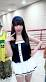
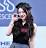
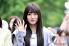
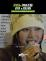
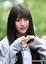
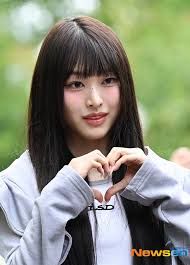
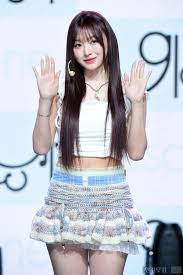
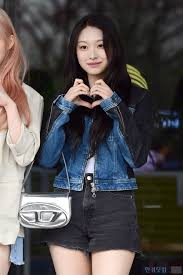
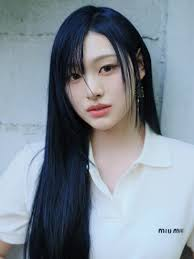
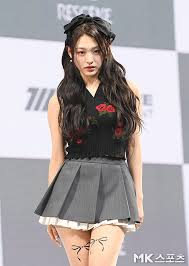
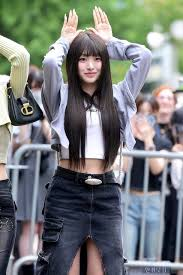
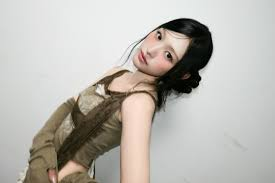
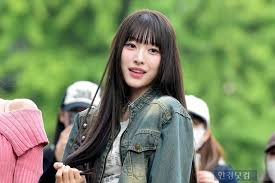
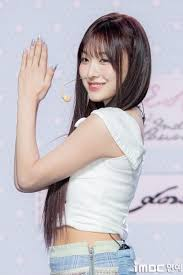
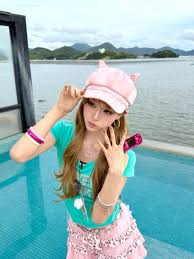
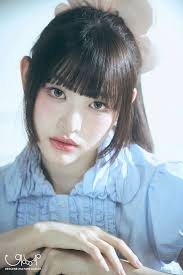
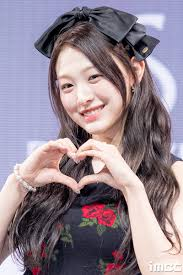
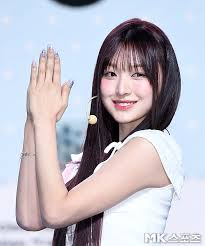
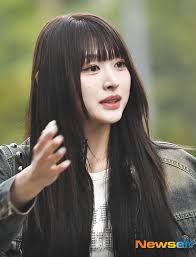
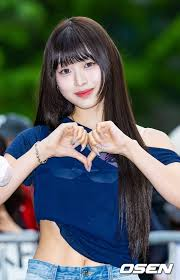
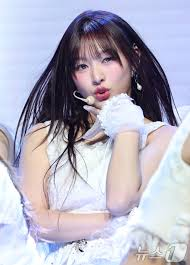
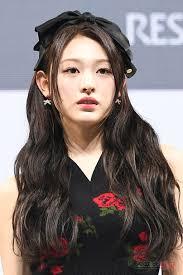
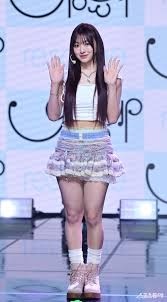
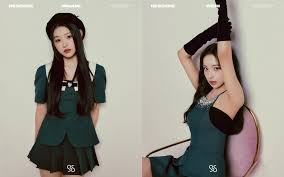
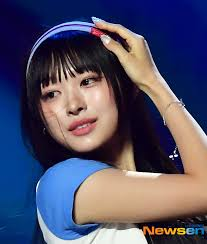
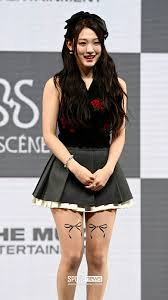
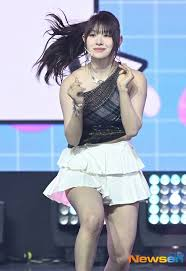
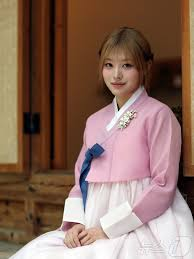
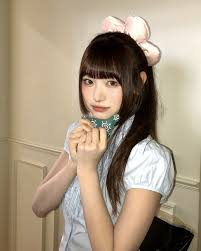
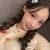
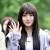
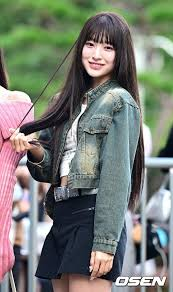
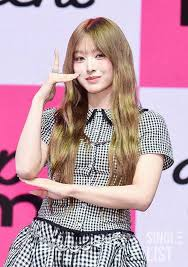
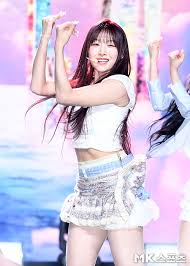
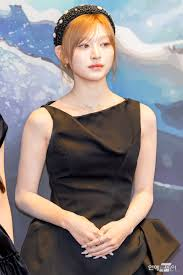
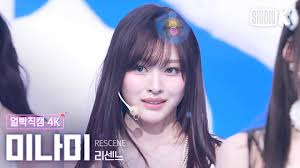
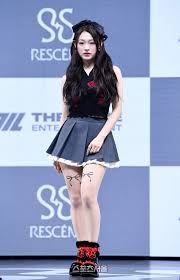
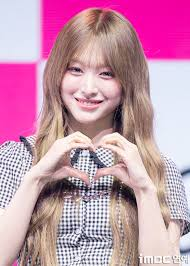
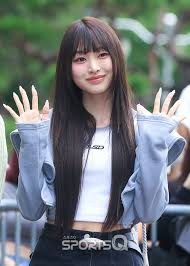
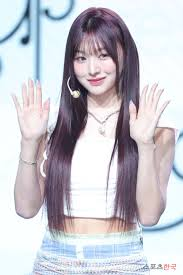
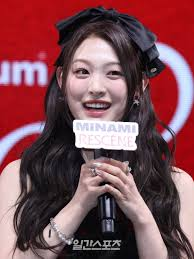
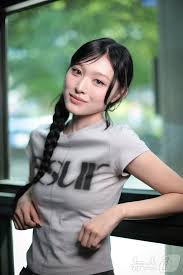
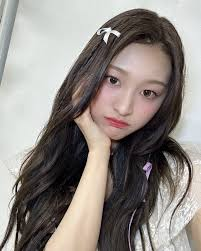
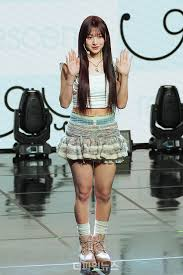
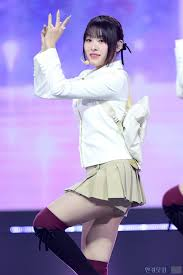
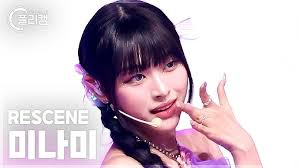
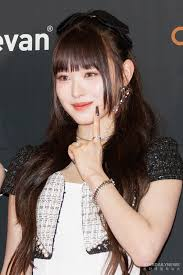
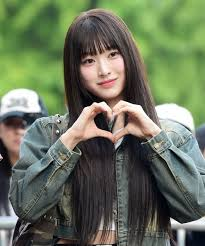
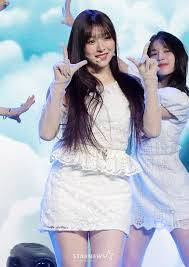
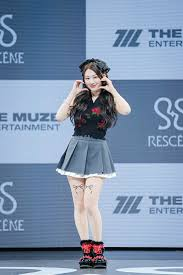
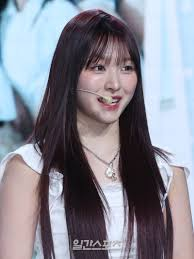
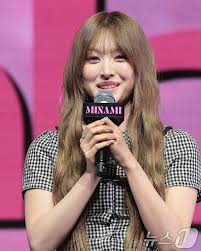
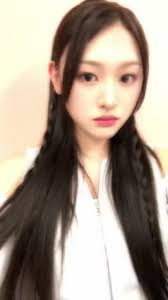
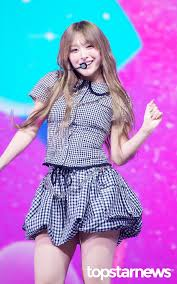
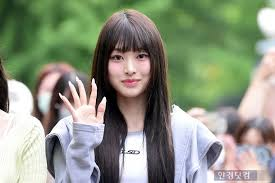
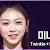
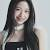
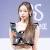
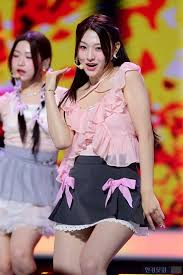
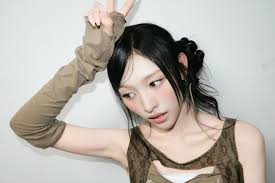
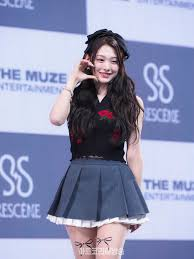
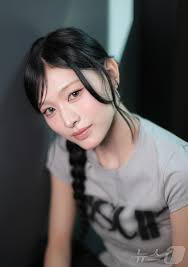
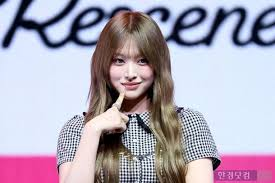
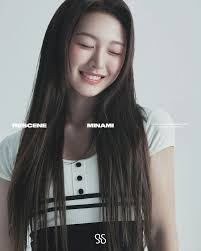
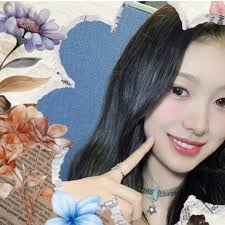
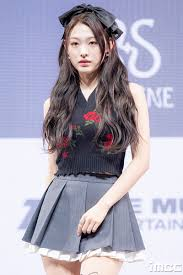
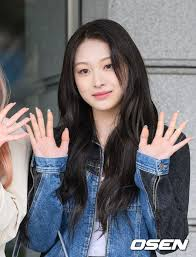
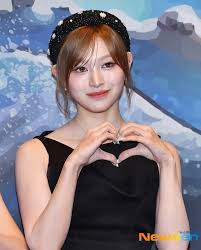
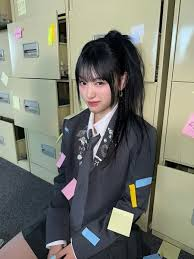
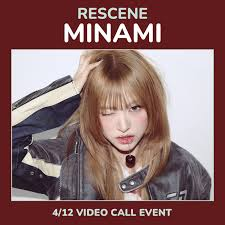
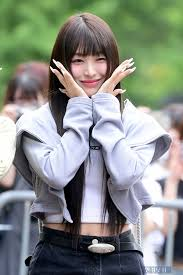
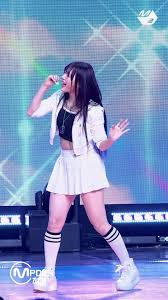
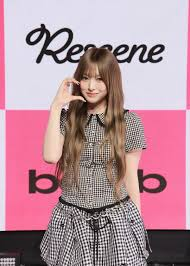
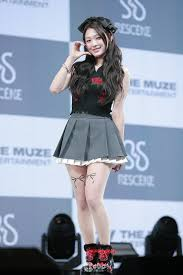
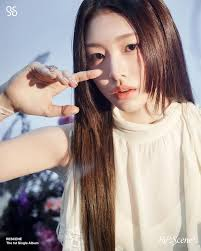
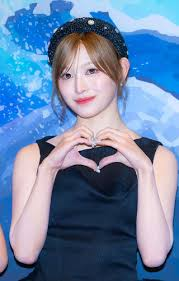
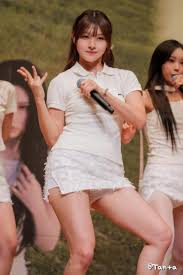
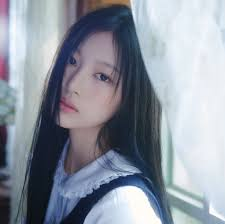
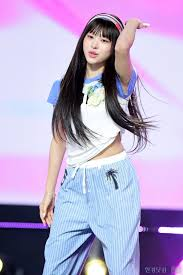

In [6]:
imgs = driver.find_elements(By.CSS_SELECTOR, "img.YQ4gaf")
imgs_src_list = [i.get_attribute("src") for i in imgs]
imgs_src_list


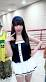

In [8]:
# 다운로드받기전에 해당 링크의 이미지를 쥬피터노트북에서 출력해보기
from IPython.display import display, Image

test_url = imgs_src_list[0]
display(Image(url=test_url))

['',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 'data:image/gif;base64,R0lGODlhAQABAIAAAP///////yH5BAEKAAEALAAAAAABAAEAAAICTAEAOw==',
 'data:image/gif;base64,R0lGODlhAQABAIAAAP///////yH5BAEKAAEALAAAAAABAAEAAAICTAEAOw==',
 'data:image/gif;base64,R0lGODlhAQABAIAAAP///////yH5BAEKAAEALAAAAAABAAEAAAICTAEAOw==',
 'data:image/gif;base64,R0lGODlhAQABAIAAAP///////yH5BAEKAAEALAAAAAABAAEAAAICTAEAOw==',
 'data:image/gif;base64,R0lGODlhAQABAIAAAP///////yH5BAEKAAEALAAAAAABAAEAAAICTAEAOw==',
 'data:image/gif;base64,R0lGODlhAQABAIAAAP///////yH5BAEKAAEALAAAAAABAAEAAAICTAEAOw==',
 'data:image/gif;base64,R0lGODlhAQABAIAAAP///////yH5BAEKAAEALAAAAAABAAEAAAICTAEAOw==',
 'data:image/gif;base64,R0lGODlhAQABAIAAAP////
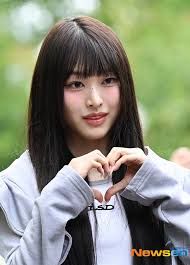
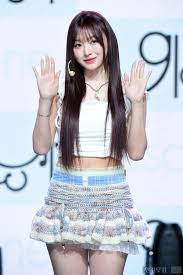
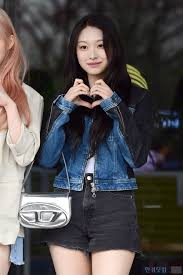
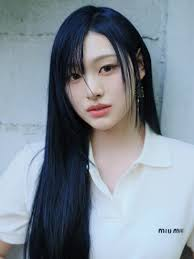
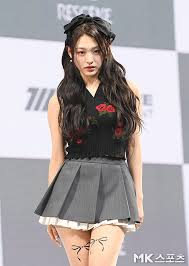
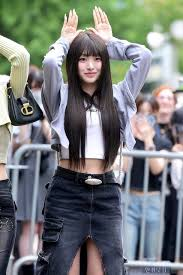
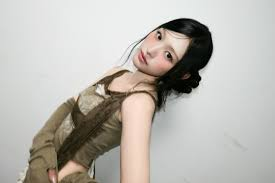
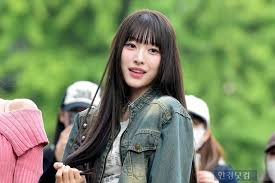
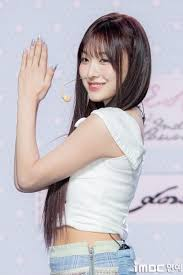
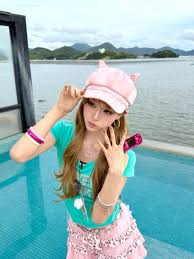
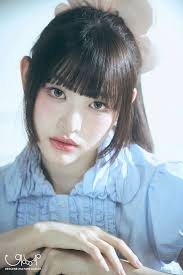
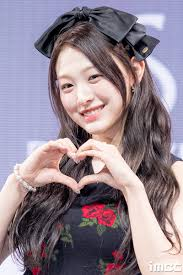
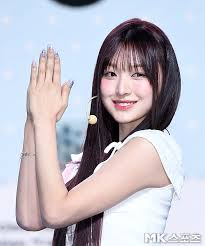
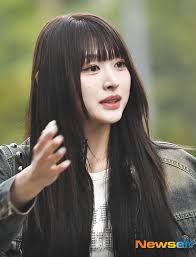
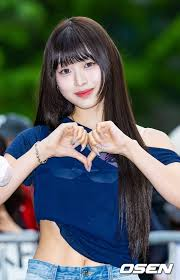
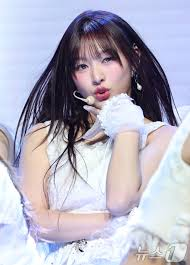
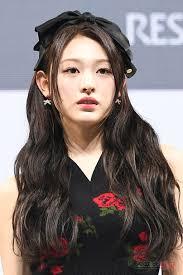
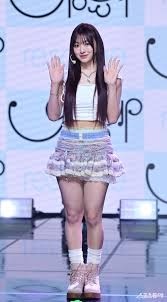
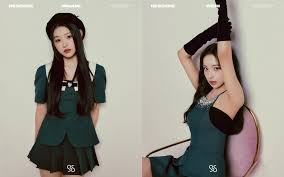
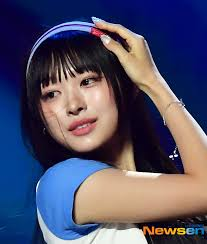
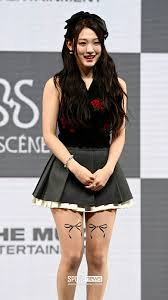
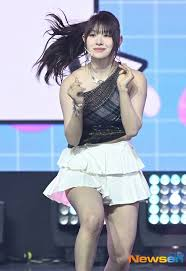
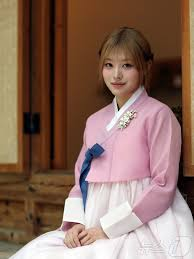
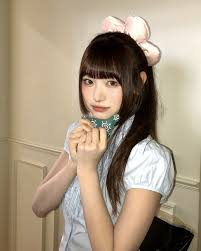
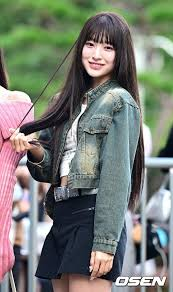
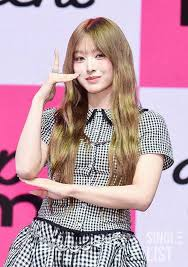
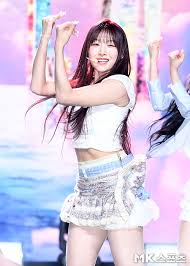
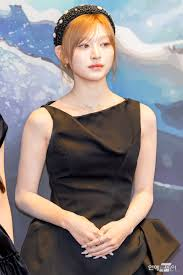
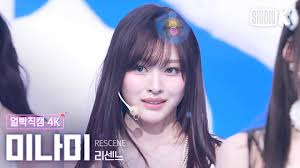
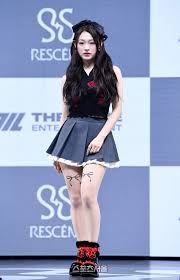
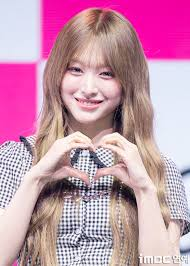
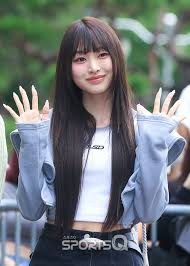
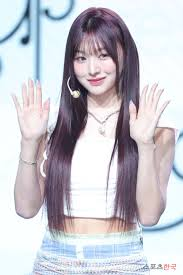
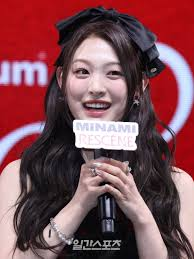
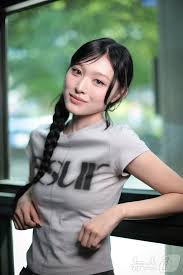
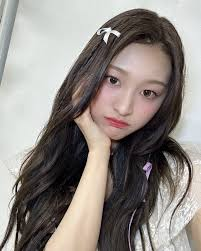
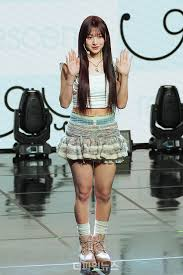
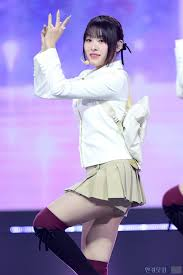
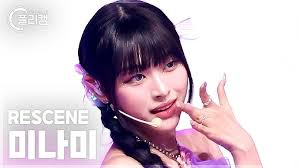
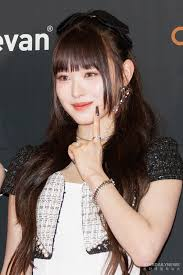
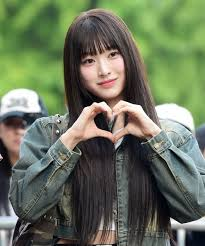
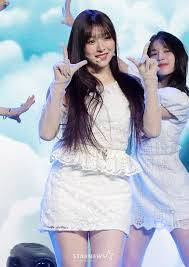
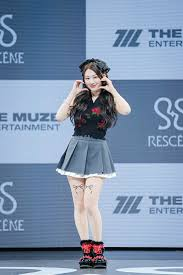
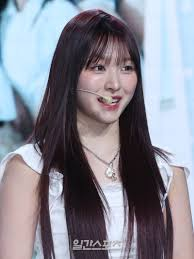
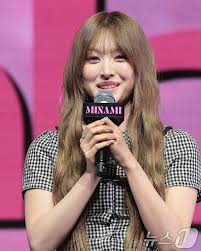
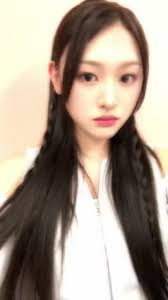
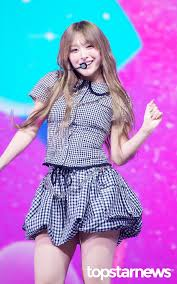
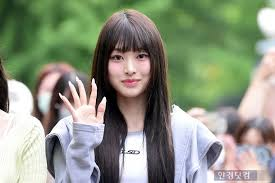
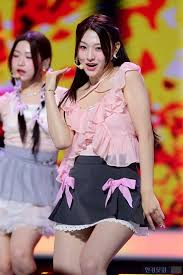
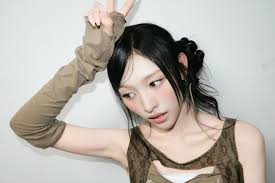
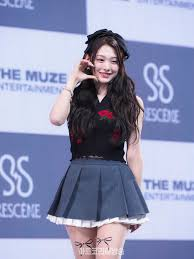
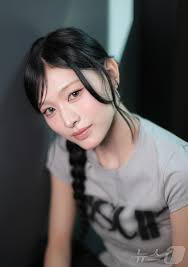
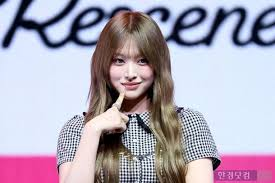
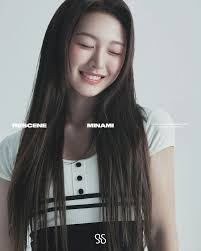
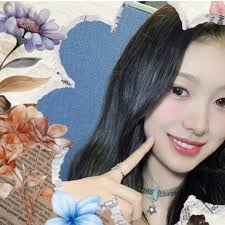
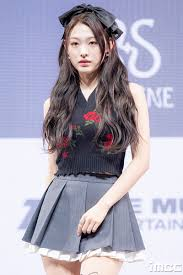
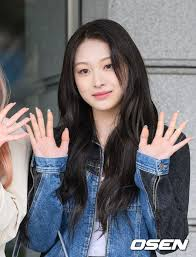
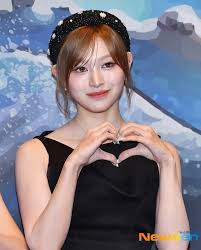
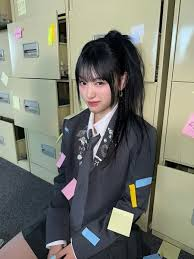
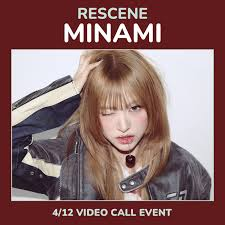
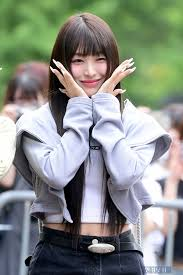
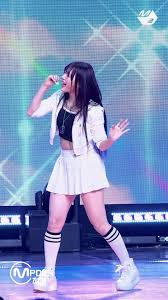
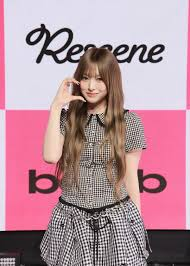
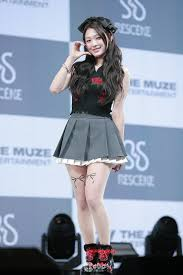
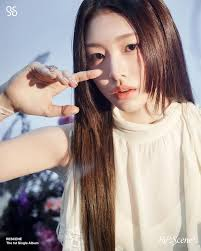
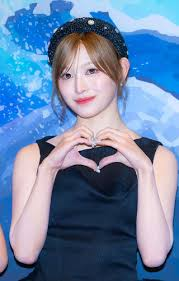
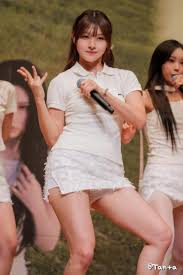
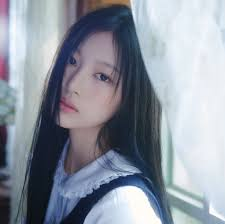
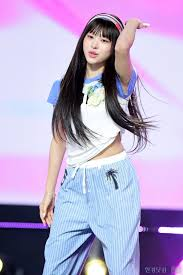

In [9]:
# 조상인 dic.H8Rx8c까지 올라가야 제대로 이미지가 나옴
imgs = driver.find_elements(By.CSS_SELECTOR, "div.H8Rx8c img.YQ4gaf")
imgs_src_list = [i.get_attribute("src") for i in imgs]
imgs_src_list


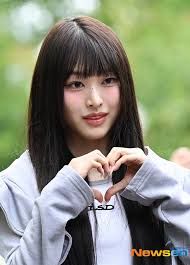

In [10]:
# 다운로드받기전에 해당 링크의 이미지를 쥬피터노트북에서 출력해보기
from IPython.display import display, Image

test_url = imgs_src_list[0]
display(Image(url=test_url))

In [11]:
# 로드 되지 않은 데이터 필터링
imgs_src_list_new = [i for i in imgs_src_list if i[:14] !="data:image/gif"]

In [12]:
len(imgs_src_list), len(imgs_src_list_new)

(100, 69)

In [16]:
# 전체 코드 작성
driver = us.Chrome() # wb 대신 us로 사용함
driver.maximize_window()
time.sleep(2)

driver.get("https://www.google.com/search?sca_esv=e8b56c3c652e1040&rlz=1C1IBEF_koKR942KR942&sxsrf=ANbL-n7umN4LVmISF3gjcq6h4Oi6MzZNGw:1780971175364&udm=2&fbs=ADc_l-bD_nyrjATWBKup7flJ4rea5XFXsPHwMjGsTekJ1HCohBAQ3Hh19DqzlO7wr7YUgTdA6AIvvuoLcS3uB5TUiBhABt596yRRtqOsYbzXfQs1vsKOVXn_6_6xPXpaJ6NYNDz3CaSZQf5MQ5_8YIZppT1spY2kiVWxs0lVQkh0JnKXReYLHL5rnUi0vNZAgCxwihgnifOBcAku7T87K5q3LqsCd6axbhexkrHgIguTGIL5add5aU0&q=%EB%A6%AC%EC%84%BC%EB%8A%90+%EB%AF%B8%EB%82%98%EB%AF%B8&sa=X&sqi=2&ved=2ahUKEwj03YzSivmUAxUOaPUHHeYlDUwQtKgLegQIGRAB&biw=1920&bih=945&dpr=1")
time.sleep(2)

# 동적문에서는 try -exect문을 사용하는 것이 좋음
try:
    for i in range(3):
        body = driver.find_element(By.TAG_NAME, "body")
        body.send_keys(Keys.END)
        time.sleep(2)

        imgs = driver.find_elements(By.CSS_SELECTOR, "div.H8Rx8c img.YQ4gaf")
        imgs_src_list = [i.get_attribute("src") for i in imgs]
        imgs_src_list_new = [i for i in imgs_src_list if i[:14] !="data:image/gif"]

        
    for idx, img in tqdm(enumerate(imgs_src_list_new)):     # 변수 두개를 받아야함 index와 요소를 받는다. url들이 img로 들어감
    # urlretrieve(url, 경로 및 파일명 설정)
        urlretrieve(img, "이미지2/"+str(idx+1)+".jpg")
        time.sleep(0.5)

    print("크롤링 완료")
    driver.quit()

except Exception as e:
    print("에러명 :",e)

280it [02:48,  1.66it/s]


KeyboardInterrupt: 

# 서울 열린데이터 광장에서 공공데이터 목록 수집

In [56]:
import re
U_A = {"User-Agent":"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/148.0.0.0 Safari/537.36"}

In [19]:
url = "https://data.seoul.go.kr/dataList/datasetList.do"
res_seoul = req.get(url, headers = U_A)
res_seoul

<Response [200]>

In [20]:
soup = bs(res_seoul.text, "lxml")
soup

<!DOCTYPE html>
<html lang="ko">
<head>
<!-- Global site tag (gtag.js) Google Analytics -->
<script async="" src="//www.googletagmanager.com/gtag/js?id=G-0T3XG23CN7"></script>
<script>
		window.dataLayer = window.dataLayer || [];
		function gtag(){dataLayer.push(arguments);}
		gtag('js', new Date());
		gtag('config', 'G-0T3XG23CN7');
	</script>
<meta content="text/html; charset=utf-8" http-equiv="Content-Type"/>
<meta content="IE=edge" http-equiv="X-UA-Compatible"/>
<meta content="" name="title"/>
<meta content="" name="keywords"/>
<meta content="" name="description"/>
<meta content="width=device-width" name="viewport"/>
<!-- meta name="viewport" content="width=device-width,initial-scale=1.0,minimum-scale=1.0,maximum-scale=1.0,user-scalable=no"/--><!-- ios때문에 이렇게 한다고하는데..w3s의 권장은 윗줄 -->
<meta content="website" property="og:type"/>
<meta content="" property="og:title"/>
<meta content="" property="og:description"/>
<meta content="https://data.seoul.go.kr:8580/resources/img/common/logo.pn

### 데이터 목록 정보 수집
- 1page의 타이틀, 분야, 수정일자(년월일 만), 제공부서(부서명 만)4개 정보 수집

In [24]:
titles = soup.select("a.goView > strong")
titles[0].text

'서울글로벌센터 접수유형 및 상담유형별(월) 상담실적\xa0'

In [94]:
# 자손선택자와 가상클래스 선택자를 활용하여 dl태그의 자손인 em태그 중 2번째에 접근
category = soup.select("dl.type-b em:nth-child(2)") # nth-child(n): em태그의 n번째에 접근
category

[<em class="stat-class-5">[복지]</em>,
 <em class="stat-class-1">[보건]</em>,
 <em class="stat-class-1">[보건]</em>,
 <em class="stat-class-1">[보건]</em>,
 <em class="stat-class-1">[보건]</em>,
 <em class="stat-class-1">[보건]</em>,
 <em class="stat-class-1">[보건]</em>,
 <em class="stat-class-5">[복지]</em>,
 <em class="stat-class-4">[산업/경제]</em>,
 <em class="stat-class-5">[복지]</em>]

In [97]:
upd_date = soup.select("dd.list-statistics-info2 > span:nth-child(1)")
upd_date

[<span>
 <b>수정일자 :</b> 
 		                                2026-06-09 
 	                                </span>,
 <span>
 <b>수정일자 :</b> 
 		                                2026-06-09 
 	                                </span>,
 <span>
 <b>수정일자 :</b> 
 		                                2026-06-09 
 	                                </span>,
 <span>
 <b>수정일자 :</b> 
 		                                2026-06-09 
 	                                </span>,
 <span>
 <b>수정일자 :</b> 
 		                                2026-06-09 
 	                                </span>,
 <span>
 <b>수정일자 :</b> 
 		                                2026-06-09 
 	                                </span>,
 <span>
 <b>수정일자 :</b> 
 		                                2026-06-09 
 	                                </span>,
 <span>
 <b>수정일자 :</b> 
 		                                2026-06-09 
 	                                </span>,
 <span>
 <b>수정일자 :</b> 
 		                                2026-06-09 
 	               

In [105]:
for i in upd_date:
    print(i.text.strip()[-10:])

2026-06-09
2026-06-09
2026-06-09
2026-06-09
2026-06-09
2026-06-09
2026-06-09
2026-06-09
2026-06-09
2026-06-09


In [113]:
dept_name = soup.select("dd.list-statistics-info2 > span:nth-child(3)")
dept_name

[<span style="width: 80%; overflow: hidden; text-overflow: ellipsis; white-space: nowrap; word-wrap: normal;">
 <b>제공부서 :</b> 
 										경제실 경제일자리기획관 금융투자과
 		                            </span>,
 <span style="width: 80%; overflow: hidden; text-overflow: ellipsis; white-space: nowrap; word-wrap: normal;">
 <b>제공부서 :</b> 
 										디지털도시국 데이터전략과
 		                            </span>,
 <span style="width: 80%; overflow: hidden; text-overflow: ellipsis; white-space: nowrap; word-wrap: normal;">
 <b>제공부서 :</b> 
 										디지털도시국 데이터전략과
 		                            </span>,
 <span style="width: 80%; overflow: hidden; text-overflow: ellipsis; white-space: nowrap; word-wrap: normal;">
 <b>제공부서 :</b> 
 										디지털도시국 정보시스템과
 		                            </span>,
 <span style="width: 80%; overflow: hidden; text-overflow: ellipsis; white-space: nowrap; word-wrap: normal;">
 <b>제공부서 :</b> 
 										시민건강국 보건의료정책과
 		                            </span>,
 <span style="width: 80%; overflow:

In [125]:
for i in dept_name:
    print(i.text.strip()[-19:])

								민생노동국 노동정책과
	경제실 경제일자리기획관 금융투자과
	경제실 경제일자리기획관 금융투자과
	경제실 경제일자리기획관 금융투자과
		노동공정상생정책관 공정경제담당관
							기후환경본부 대기정책과
							기후환경본부 대기정책과
							기후환경본부 대기정책과
							기후환경본부 대기정책과
		주택실 주택정책관 주거환경개선과


### 1~5 page의 정보들에 접근
- 웹 페이지 내부 데이터가 수집은 되지만 page를 변경하기 위해 2,3page의 url을 확인해보니 page에 대한 정보가 url에 포함되어 있지 않음
- 첫 페이지를 제외한 이후부터는 통신방식이 post로 되어있음
- 검색 엔진들은 기본적으로 get요청만 사용하여 웹 페이지를 수집하는데 첫페이지 부터 post로 설정해두면 검색결과에 노출이 되지 않기 때문에 처음엔 GET으로 동작함

### 2page 정보 수집

In [120]:
url = "https://data.seoul.go.kr/dataList/datasetList.do"

paylod = {"pageIndex": 2}   # Post방식의 웹페이지에서 페이지 지정

# POST 방식으로 요청 보내기
res_seoul = req.post(url, data=paylod, headers = U_A)
res_seoul

<Response [200]>

In [121]:
soup = bs(res_seoul.text, "lxml")

In [122]:
titles = soup.select("a.goView > strong")

for i in titles:
    print(i.text)

서울시 노동조합 현황 
서울글로벌센터 상담유형별(월) 상담실적 
서울글로벌센터 상담유형별(분기) 상담실적 
서울글로벌센터 접수유형별 언어별 상담실적 
서울시 대부업체 정보 
서울시 실시간 자치구별 대기환경 현황 
서울시 도로변/입체대기 측정소별 실시간 대기환경 현황 
서울시 기간별 시간평균 대기환경 정보 
서울시 시간 평균 대기오염도 정보 
서울시 집수리닷컴 공지사항 


In [123]:
dept_name = soup.select("dd.list-statistics-info2 > span:nth-child(3)")

for i in dept_name:
    print(i.text.strip()[19:])

민생노동국 노동정책과
경제실 경제일자리기획관 금융투자과
경제실 경제일자리기획관 금융투자과
경제실 경제일자리기획관 금융투자과
노동공정상생정책관 공정경제담당관
기후환경본부 대기정책과
기후환경본부 대기정책과
기후환경본부 대기정책과
기후환경본부 대기정책과
주택실 주택정책관 주거환경개선과


In [129]:
import pandas as pd

### 1~5page 정보 수집후 데이터 프레임으로 만들기

In [152]:
titles_list, category_list, upd_date_list, dept_name_list = [], [], [], []
for page in tqdm(range(1,6)):
    url = "https://data.seoul.go.kr/dataList/datasetList.do"
    paylod = {"pageIndex": page}   
    res_seoul = req.post(url, data=paylod, headers = U_A)
    soup = bs(res_seoul.text, "lxml")
    
    
    titles = soup.select("a.goView > strong")
    category = soup.select("dl.type-b em:nth-child(2)")
    upd_date = soup.select("dd.list-statistics-info2 > span:nth-child(1)")
    dept_name = soup.select("dd.list-statistics-info2 > span:nth-child(3)")

    
    for i in range(len(titles)):
        titles_list.append(titles[i].text.strip())
        category_list.append(category[i].text.strip()[1:-1])
        upd_date_list.append(upd_date[i].text.strip()[-10:])
        dept_name_list.append(dept_name[i].text.strip()[19:])

soup_df = pd.DataFrame({"타이틀": titles_list,
        "분야": category_list,
        "수정일자": upd_date_list,
        "제공부서":dept_name_list},
        index=range(1, len(titles_list) + 1))

soup_df.index.name = "No"
       
soup_df 

100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  1.71it/s]


,타이틀,분야,수정일자,제공부서
No,,,,
1,서울시 지역 시간별 수질 현황,도시관리,2026-06-09,서울아리수본부 본부 급수부 급수운영과
2,서울시 하수관로 수위 현황,도시관리,2026-06-09,물순환안전국 물재생계획과
3,서울글로벌센터 접수유형 및 상담유형별(월) 상담실적,복지,2026-06-09,경제실 경제일자리기획관 금융투자과
4,상상대로 서울 자유제안 정보,일반행정,2026-06-09,홍보기획관 콘텐츠담당관
5,서울시 세척제 제조업 현황,보건,2026-06-09,디지털도시국 데이터전략과
6,서울시 위생처리업 현황,보건,2026-06-09,디지털도시국 데이터전략과
7,서울시 중구 위생처리업 공중위생업소 현황,보건,2026-06-09,디지털도시국 정보시스템과
8,서울시 기타 위생용품 제조업 현황,보건,2026-06-09,시민건강국 보건의료정책과
9,서울시 식품위생업소 현황,보건,2026-06-09,디지털도시국 데이터전략과
